# AuraMind V3 — Personal Project Notebook
## Multi-Turn Empathetic Emotional-Support Dialogue Decoder

### End-to-end reproducible personal ML project pipeline

**Dataset V2 → Quality-controlled synthetic augmentation → Byte-Level BPE → RoPE/RMSNorm/SwiGLU Decoder → Training → Held-out evaluation → Generation → Artifact integrity report**

This notebook documents AuraMind as a self-directed machine-learning project. It keeps real and synthetic data explicitly separated, evaluates on held-out real data, records measured tokenizer/model metrics, and produces checksummed artifacts for reproducibility.

> **Important:** This is a research prototype for empathetic dialogue generation, not a medical or psychiatric diagnostic system.


In [1]:
# ============================================================
# 0. ENVIRONMENT — COLAB / PERSONAL PROJECT
# ============================================================

!pip -q install tokenizers accelerate matplotlib tqdm

import os
import sys
import math
import time
import json
import hashlib
import random
import unicodedata
import re
import csv
import tarfile
import shutil
import urllib.request
import urllib.error
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 78)
print("AURAMIND PERSONAL PROJECT — ENVIRONMENT")
print("=" * 78)
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Device:", device)

if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM: {props.total_memory / 1024**3:.2f} GB")
    print("CUDA:", torch.version.cuda)
else:
    print("⚠️ CPU mode. A GPU runtime is strongly recommended.")

print("Seed:", SEED)


AURAMIND PERSONAL PROJECT — ENVIRONMENT
Python: 3.13.15
PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4
VRAM: 14.56 GB
CUDA: 12.8
Seed: 42


## 1. Project configuration (Enhanced V3.2)

Enhanced with:
- **Emotion-Conditioned Token Prefixing**: Prepends `<|emotion|> {emotion}\n` using EmpatheticDialogues ground-truth context and domain tags, eliminating sentiment inversion ('toxic positivity').
- **Min-$p$ Sampling**: Dynamically filters improbable noise tokens relative to the top candidate probability ($p < \text{min\_p} \times p_{\max}$).
- **Response-Only Loss Masking**: Masks `<|emotion|>` and `<|user|>` tokens with `PAD_ID` so the model focuses 100% of gradient updates on generating counselor responses.
- **Repetition Penalty**: Prevents repetitive empathetic loops in auto-regressive generation.
- **KV-Cached Generation**: $O(N)$ autoregressive token generation.
- **Perplexity Diagnostics**: Real-time evaluation tracking.


In [2]:
# ============================================================
# 1. CONFIGURATION
# ============================================================

PROJECT = "AuraMind"
VERSION = "V3-PERSONAL-PROJECT"

ROOT = Path("/content/auramind")
DATA_DIR = ROOT / "data" / "v2"
RAW_DIR = DATA_DIR / "raw"
ARTIFACT_DIR = ROOT / "artifacts"
CHECKPOINT_DIR = ROOT / "checkpoints"

for path in [
    RAW_DIR,
    DATA_DIR,
    ARTIFACT_DIR,
    CHECKPOINT_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

# Dataset controls
TARGET_SYNTHETIC = 10_000
REAL_TRAIN_FRACTION = 0.80
REAL_VAL_FRACTION = 0.10

# Model controls
VOCAB_TARGET = 4096

# 384-token context keeps more multi-turn dialogue history
# while remaining practical on a consumer/Colab GPU.
BLOCK_SIZE = 384

N_LAYER = 6
N_HEAD = 6
N_EMBD = 384
DROPOUT = 0.10

# Data representation
# Preserve dialogue boundaries instead of concatenating unrelated
# conversations into one continuous language-model stream.
PRESERVE_DIALOGUE_BOUNDARIES = True

# ENHANCEMENT: Response-only loss masking
# Focuses 100% of gradient capacity on counselor turns
MASK_USER_LOSS = True

# ENHANCEMENT: Repetition penalty (Keskar et al., 2019)
REPETITION_PENALTY = 1.15

# ENHANCEMENT: KV Caching
USE_KV_CACHE = True

# ENHANCEMENT: Emotion Prefixing & Min-p sampling
EMOTION_TOKEN = "<|emotion|>"
MIN_P = 0.05

N_LAYER = 6
N_HEAD = 6
N_EMBD = 384
DROPOUT = 0.10

# Training controls
FINAL_TRAIN_STEPS = 3_000
SMOKE_TEST = False
SMOKE_STEPS = 25
EVAL_INTERVAL = 50
EVAL_BATCHES = 25
WARMUP_STEPS = 75

MAX_LR = 6e-4
MIN_LR = 6e-5
WEIGHT_DECAY = 0.10
GRAD_CLIP = 1.0

# Resume behavior
RESUME_TRAINING = True

# Safety / quality controls
SEMANTIC_DUP_THRESHOLD = 0.88
QUALITY_THRESHOLD = 22.0

# If a previous complete Dataset V2 is present, reuse it.
REUSE_EXISTING_DATASET = True

if SMOKE_TEST:
    TOTAL_STEPS = SMOKE_STEPS
else:
    TOTAL_STEPS = FINAL_TRAIN_STEPS

print("Project:", PROJECT)
print("Version:", VERSION)
print("Training steps:", TOTAL_STEPS)
print("Target synthetic dialogues:", TARGET_SYNTHETIC)


Project: AuraMind
Version: V3-PERSONAL-PROJECT
Training steps: 3000
Target synthetic dialogues: 10000


## 2. Local project logging

The notebook is self-contained and does not connect to external experiment-tracking services. Progress is logged locally so the experiment remains reproducible and portable.


In [3]:
# ============================================================
# 2. LOCAL PROJECT LOGGING
# ============================================================

def project_stage(stage, progress, detail):
    print(f"[PROJECT] {stage} | {progress}% | {detail}")

def project_metric(payload):
    # Metrics are retained locally in notebook outputs and artifacts.
    return None


## 3. Dataset V2 — real EmpatheticDialogues

The Hugging Face dataset-script route that previously failed is intentionally avoided. The notebook downloads the original EmpatheticDialogues archive directly and reconstructs conversations by `conv_id`.

**Critical split rule:** the real dataset is split into 80/10/10 **before** synthetic data is added. Synthetic examples can enter training only.


In [4]:
# ============================================================
# 3. DOWNLOAD + RECONSTRUCT REAL DATA
# ============================================================

project_stage(
    "dataset_preparation",
    20,
    "Downloading and reconstructing real EmpatheticDialogues",
)

TAR_URL = (
    "https://dl.fbaipublicfiles.com/parlai/"
    "empatheticdialogues/empatheticdialogues.tar.gz"
)

TAR_PATH = RAW_DIR / "empatheticdialogues.tar.gz"

if not TAR_PATH.exists():
    print("📥 Downloading EmpatheticDialogues archive...")
    urllib.request.urlretrieve(
        TAR_URL,
        TAR_PATH,
    )

# Locate train.csv robustly regardless of archive subdirectory name.
csv_candidates = list(RAW_DIR.rglob("train.csv"))

if not csv_candidates:
    print("📦 Extracting archive...")
    with tarfile.open(TAR_PATH, "r:gz") as archive:
        archive.extractall(RAW_DIR)
    csv_candidates = list(RAW_DIR.rglob("train.csv"))

if not csv_candidates:
    raise FileNotFoundError(
        "train.csv was not found after downloading/extracting "
        "EmpatheticDialogues."
    )

TRAIN_CSV = csv_candidates[0]
print("Using:", TRAIN_CSV)

def clean_text(text):
    if not text:
        return ""

    text = unicodedata.normalize(
        "NFKC",
        text,
    )

    text = "".join(
        ch
        for ch in text
        if (
            ch == "\n"
            or unicodedata.category(ch)[0] != "C"
        )
    )

    text = text.replace(
        "_comma_",
        ",",
    )

    return " ".join(
        text.split()
    ).strip()

conversations = defaultdict(list)
conv_emotions = {}

with open(
    TRAIN_CSV,
    "r",
    encoding="utf-8",
    errors="replace",
) as handle:

    reader = csv.DictReader(handle)

    required = {
        "conv_id",
        "utterance",
    }

    if not required.issubset(
        set(reader.fieldnames or [])
    ):
        raise ValueError(
            f"Unexpected EmpatheticDialogues columns: "
            f"{reader.fieldnames}"
        )

    for row in reader:

        conv_id = (
            row.get("conv_id") or ""
        ).strip()

        utterance = clean_text(
            row.get("utterance") or ""
        )

        context_emotion = clean_text(
            row.get("context") or ""
        ).lower()

        if conv_id:
            if context_emotion and conv_id not in conv_emotions:
                conv_emotions[conv_id] = context_emotion
            if utterance:
                conversations[
                    conv_id
                ].append(
                    utterance
                )

real_records = []
seen = set()

for conv_id, turns in conversations.items():

    if len(turns) < 2:
        continue

    lines = []
    emotion = conv_emotions.get(conv_id, "").strip()
    if emotion:
        lines.append(f"{EMOTION_TOKEN} {emotion}")

    for index, utterance in enumerate(turns):

        role = (
            "<|user|>"
            if index % 2 == 0
            else "<|counselor|>"
        )

        lines.append(
            f"{role} {utterance}"
        )

    doc = (
        "\n".join(lines)
        + " <|eos|>"
    )

    digest = hashlib.sha256(
        doc.encode("utf-8")
    ).hexdigest()

    if digest in seen:
        continue

    seen.add(digest)

    real_records.append(
        {
            "id": (
                f"real_{len(real_records) + 1:06d}"
            ),
            "doc": doc,
            "hash": digest,
            "source": "real_empathetic",
            "provider": "facebook_empathetic_dialogues",
            "emotion": emotion,
        }
    )

if len(real_records) < 100:
    raise RuntimeError(
        "Too few reconstructed conversations; "
        "dataset extraction likely failed."
    )

random.seed(SEED)
random.shuffle(real_records)

n_real = len(real_records)

split_train = int(
    REAL_TRAIN_FRACTION * n_real
)

split_val = int(
    (
        REAL_TRAIN_FRACTION
        + REAL_VAL_FRACTION
    )
    * n_real
)

real_train = real_records[
    :split_train
]

real_val = real_records[
    split_train:split_val
]

real_test = real_records[
    split_val:
]

print("=" * 78)
print("REAL DATASET")
print("=" * 78)
print("Total dialogues:", len(real_records))
print("Real train:", len(real_train))
print("Real validation:", len(real_val))
print("Real test:", len(real_test))


[PROJECT] dataset_preparation | 20% | Downloading and reconstructing real EmpatheticDialogues
📥 Downloading EmpatheticDialogues archive...
📦 Extracting archive...


/tmp/ipykernel_800/3860481738.py:31: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(RAW_DIR)


Using: /content/auramind/data/v2/raw/empatheticdialogues/train.csv
REAL DATASET
Total dialogues: 17780
Real train: 14224
Real validation: 1778
Real test: 1778


## 4. Synthetic scenario engine + transparent provenance

The fallback generator is deliberately explicit. If no teacher API is configured, examples are labelled `template_synthetic_fallback`; they are **not** falsely described as Gemini/OpenAI outputs.


In [5]:
# ============================================================
# 4. SYNTHETIC SCENARIO BANK
# ============================================================

DOMAINS = {
    "ACADEMIC": [
        "anxious",
        "overwhelmed",
        "discouraged",
        "ashamed",
        "exhausted",
    ],
    "CAREER": [
        "undervalued",
        "uncertain",
        "overwhelmed",
        "self-doubting",
        "burned out",
    ],
    "RELATIONSHIPS": [
        "lonely",
        "misunderstood",
        "disconnected",
        "hurt",
        "uncertain",
    ],
    "FAMILY": [
        "guilty",
        "unheard",
        "conflicted",
        "burdened",
        "frustrated",
    ],
    "LIFE_TRANSITIONS": [
        "disoriented",
        "apprehensive",
        "vulnerable",
        "uncertain",
        "unmoored",
    ],
    "PERSONAL_GROWTH": [
        "self-critical",
        "stagnant",
        "impatient",
        "confused",
        "discouraged",
    ],
}

ACADEMIC_ENTITIES = [
    "my exam",
    "my final project",
    "my coursework",
    "my upcoming presentation",
]

CAREER_ENTITIES = [
    "my new job",
    "my team",
    "my career transition",
    "my workload",
]

GENERAL_ENTITIES = [
    "my relationship",
    "my family situation",
    "this life transition",
    "my personal goals",
]

OPENERS = [
    "I have been feeling {emotion} about {entity} {timeframe}.",
    "Lately I keep thinking about {entity}, and I feel really {emotion}.",
    "I am struggling with {entity} {timeframe}, and it has left me feeling {emotion}.",
    "Every time I think about {entity}, I get this strong feeling of being {emotion}.",
]

VALIDATIONS = [
    "It sounds like {entity} has been carrying a lot of emotional weight for you. It makes sense that you would feel {emotion}.",
    "I hear how much pressure you have been carrying around {entity}. Thank you for putting that experience into words.",
    "That sounds genuinely difficult. Having so much uncertainty around {entity} can leave a person feeling emotionally worn down.",
    "I can hear how important {entity} is to you, and how exhausting it has been to sit with these feelings.",
]

FOLLOWUPS = [
    "What part of this feels hardest to sit with right now?",
    "Which part of the situation is taking up the most space in your mind?",
    "What would feeling a little more supported look like for you today?",
    "Have you noticed a particular moment when these feelings become strongest?",
]

USER_TURNS = [
    "I keep comparing myself with other people, and then I feel like I am falling behind.",
    "I know I cannot control everything, but my mind keeps jumping to the worst possible outcome.",
    "I have been trying to stay productive, but sometimes I just need permission to slow down.",
    "I think I have been much harder on myself than I would ever be on someone I care about.",
]

RESPONSES = [
    "That comparison sounds exhausting. You do not have to solve the whole situation at once; it may help to notice what you are feeling without treating the feeling as a verdict about your worth.",
    "It sounds like your mind is trying to protect you by preparing for every possible outcome. We can make room for that fear without assuming the worst-case scenario will happen.",
    "It is understandable to want a little room to breathe. Taking things one manageable step at a time can be kinder than demanding certainty from yourself.",
    "That self-criticism sounds heavy. If it helps, you might ask what you would say to someone you cared about who was facing exactly the same situation.",
]

CLOSINGS = [
    "You do not need to have everything figured out in this moment.",
    "For now, it may be enough to give yourself a little patience and notice what you need.",
    "We can stay with what is happening right now rather than rushing toward a perfect answer.",
    "Your feelings are worth taking seriously, even when you are still figuring out what they mean.",
]

TIMEFRAMES = [
    "tonight",
    "this week",
    "before my next deadline",
    "lately",
    "over the last few days",
]

def build_synthetic_dialogue(index):
    domain = random.choice(
        list(DOMAINS)
    )

    emotion = random.choice(
        DOMAINS[domain]
    )

    if domain == "ACADEMIC":
        entity = random.choice(
            ACADEMIC_ENTITIES
        )
    elif domain == "CAREER":
        entity = random.choice(
            CAREER_ENTITIES
        )
    else:
        entity = random.choice(
            GENERAL_ENTITIES
        )

    timeframe = random.choice(
        TIMEFRAMES
    )

    difficulty = (
        (index - 1) % 10
    ) + 1

    opening = random.choice(
        OPENERS
    ).format(
        emotion=emotion,
        entity=entity,
        timeframe=timeframe,
    )

    validation = random.choice(
        VALIDATIONS
    ).format(
        emotion=emotion,
        entity=entity,
    )

    followup = random.choice(
        FOLLOWUPS
    )

    user2 = random.choice(
        USER_TURNS
    )

    response2 = random.choice(
        RESPONSES
    )

    closing = random.choice(
        CLOSINGS
    )

    if difficulty <= 2:

        turns = [
            f"<|user|> {opening}",
            (
                f"<|counselor|> "
                f"{validation} "
                f"{followup}"
            ),
        ]

    elif difficulty <= 5:

        turns = [
            f"<|user|> {opening}",
            f"<|counselor|> {validation}",
            f"<|user|> {user2}",
            (
                f"<|counselor|> "
                f"{response2} "
                f"{followup}"
            ),
        ]

    else:

        turns = [
            f"<|user|> {opening}",
            (
                f"<|counselor|> "
                f"{validation}"
            ),
            f"<|user|> {user2}",
            (
                f"<|counselor|> "
                f"{response2}"
            ),
            (
                f"<|user|> "
                f"I think I need to stop expecting "
                f"myself to resolve everything immediately."
            ),
            (
                f"<|counselor|> "
                f"{closing}"
            ),
        ]

    prefix = f"{EMOTION_TOKEN} {emotion}\n"
    return prefix + "\n".join(turns) + " <|eos|>"

print(
    "Scenario bank:",
    len(DOMAINS),
    "domains"
)


Scenario bank: 6 domains


## 5. Safety filter

The filter rejects unsupported medical/psychiatric diagnosis language, fake credentials, and deterministic physiological claims. It does not attempt to diagnose users.


In [6]:
# ============================================================
# 5. SAFETY GUARDRAIL
# ============================================================

UNSAFE_PATTERNS = [
    r"\byou (have|are suffering from|definitely have)\b",
    r"\bi diagnose you\b",
    r"\byou are diagnosed with\b",
    r"\byour symptoms prove\b",
    r"\byour heartbeat is definitely caused by\b",
    r"\byour blood pressure is definitely\b",
    r"\bi am a (doctor|psychiatrist|psychologist)\b",
    r"\bas your doctor\b",
    r"\bthis is definitely a psychiatric\b",
]

UNSAFE_REGEX = [
    re.compile(
        pattern,
        re.IGNORECASE,
    )
    for pattern in UNSAFE_PATTERNS
]

def safety_filter(text):
    for pattern in UNSAFE_REGEX:
        if pattern.search(text):
            return False, pattern.pattern

    return True, None

def validate_structure(text):
    required = [
        "<|user|>",
        "<|counselor|>",
        "<|eos|>",
    ]

    if not all(
        token in text
        for token in required
    ):
        return False

    if text.count(
        "<|user|>"
    ) < 1:
        return False

    if text.count(
        "<|counselor|>"
    ) < 1:
        return False

    return True

# Test guardrail itself.
assert safety_filter(
    "Your feelings sound difficult, and we can explore them."
)[0]

assert not safety_filter(
    "You definitely have a psychiatric disorder."
)[0]

print("✅ Safety guardrail self-test passed.")


✅ Safety guardrail self-test passed.


## 6. Five-dimension quality judge

This is a **heuristic judge**, not a human or LLM judge. Its scores are computed from observable dialogue properties and are recorded as such.


In [7]:
# ============================================================
# 6. TRANSPARENT HEURISTIC QUALITY JUDGE
# ============================================================

EMPATHY_MARKERS = [
    "sounds",
    "hear",
    "understandable",
    "difficult",
    "hard",
    "pressure",
    "feel",
    "carrying",
    "exhausting",
    "thank you",
]

RELEVANCE_MARKERS = [
    "situation",
    "right now",
    "today",
    "this",
    "part",
    "situation",
    "what",
]

DIRECTIVE_PATTERNS = [
    r"\byou must\b",
    r"\byou need to\b",
    r"\bjust do\b",
    r"\byou should definitely\b",
    r"\bthe answer is\b",
]

MEDICAL_PATTERNS = [
    r"\bdiagnos",
    r"\bdisorder\b",
    r"\bmedication\b",
    r"\bprescription\b",
    r"\bpsychiatric\b",
    r"\bmedical condition\b",
]

def extract_roles(text):
    pieces = re.split(
        r"(<\|user\|>|<\|counselor\|>)",
        text,
    )

    current = None
    users = []
    counselors = []

    for piece in pieces:

        if piece == "<|user|>":
            current = "user"

        elif piece == "<|counselor|>":
            current = "counselor"

        elif current == "user":
            if piece.strip():
                users.append(
                    piece.strip()
                )

        elif current == "counselor":
            if piece.strip():
                counselors.append(
                    piece.strip()
                )

    return users, counselors

def count_hits(text, markers):
    lower = text.lower()
    return sum(
        marker in lower
        for marker in markers
    )

def score_dialogue(text):
    users, counselors = extract_roles(text)

    counselor_text = " ".join(
        counselors
    )

    all_text = text.lower()

    # 1. Empathy
    empathy_hits = count_hits(
        counselor_text,
        EMPATHY_MARKERS,
    )
    empathy = min(
        5.0,
        3.0 + 0.4 * min(
            empathy_hits,
            5,
        ),
    )

    # 2. Relevance
    relevance_hits = count_hits(
        counselor_text,
        RELEVANCE_MARKERS,
    )
    relevance = min(
        5.0,
        3.2 + 0.36 * min(
            relevance_hits,
            5,
        ),
    )

    # 3. Coherence
    turn_balance = (
        min(len(users), len(counselors))
        / max(
            len(users),
            len(counselors),
            1,
        )
    )

    coherence = (
        4.0
        + 1.0 * turn_balance
    )

    if len(counselors) == 0:
        coherence = 1.0

    # 4. Non-directiveness
    directive_hits = sum(
        len(
            re.findall(
                pattern,
                counselor_text,
                re.IGNORECASE,
            )
        )
        for pattern in DIRECTIVE_PATTERNS
    )

    non_directive = max(
        0.0,
        5.0 - 0.75 * directive_hits,
    )

    # 5. Non-medicalization
    medical_hits = sum(
        len(
            re.findall(
                pattern,
                all_text,
                re.IGNORECASE,
            )
        )
        for pattern in MEDICAL_PATTERNS
    )

    non_medical = max(
        0.0,
        5.0 - 1.5 * medical_hits,
    )

    scores = {
        "empathy": round(
            min(empathy, 5.0),
            2,
        ),
        "relevance": round(
            min(relevance, 5.0),
            2,
        ),
        "coherence": round(
            min(coherence, 5.0),
            2,
        ),
        "non_directiveness": round(
            min(non_directive, 5.0),
            2,
        ),
        "non_medicalization": round(
            min(non_medical, 5.0),
            2,
        ),
    }

    scores["total_score"] = round(
        sum(scores.values()),
        2,
    )

    scores["judge_type"] = (
        "heuristic_judge"
    )

    scores["threshold"] = (
        QUALITY_THRESHOLD
    )

    scores["passed"] = (
        scores["total_score"]
        >= QUALITY_THRESHOLD
    )

    return scores

sample_score = score_dialogue(
    build_synthetic_dialogue(1)
)

print(
    json.dumps(
        sample_score,
        indent=2,
    )
)


{
  "empathy": 4.2,
  "relevance": 3.56,
  "coherence": 5.0,
  "non_directiveness": 5.0,
  "non_medicalization": 5.0,
  "total_score": 22.76,
  "judge_type": "heuristic_judge",
  "threshold": 22.0,
  "passed": true
}


## 7. Semantic deduplication

Exact SHA-256 duplicates are removed first. Near-duplicates are compared with a deterministic TF-IDF-like sparse character/word feature representation and cosine similarity.


In [8]:
# ============================================================
# 7. EXACT + SEMANTIC DEDUPLICATION
# ============================================================

class SemanticDeduplicator:

    def __init__(
        self,
        threshold=0.88,
    ):
        self.threshold = threshold
        self.exact_hashes = set()
        self.vectors = []
        self.term_index = defaultdict(list)

        self.exact_duplicates = 0
        self.semantic_duplicates = 0

    @staticmethod
    def features(text):

        lower = text.lower()

        words = re.findall(
            r"[a-z0-9']+",
            lower,
        )

        word_features = [
            f"w:{word}"
            for word in words
            if len(word) > 2
        ]

        char_features = [
            "c:" + lower[i:i+4]
            for i in range(
                max(
                    0,
                    len(lower) - 3,
                )
            )
        ]

        counts = Counter(
            word_features
            + char_features
        )

        norm = math.sqrt(
            sum(
                value * value
                for value in counts.values()
            )
        )

        return counts, norm

    def accept(self, text):

        digest = hashlib.sha256(
            text.encode("utf-8")
        ).hexdigest()

        if digest in self.exact_hashes:
            self.exact_duplicates += 1
            return False

        vector, norm = self.features(
            text
        )

        if norm == 0:
            return False

        candidate_ids = set()

        # Candidate pruning through feature index.
        for term in vector:

            ids = self.term_index.get(
                term,
                [],
            )

            candidate_ids.update(
                ids[-8:]
            )

            if len(candidate_ids) >= 40:
                break

        for candidate_id in candidate_ids:

            old_vector, old_norm = (
                self.vectors[candidate_id]
            )

            shared = (
                set(vector)
                & set(old_vector)
            )

            dot = sum(
                vector[k]
                * old_vector[k]
                for k in shared
            )

            similarity = (
                dot
                / max(
                    norm * old_norm,
                    1e-12,
                )
            )

            if (
                similarity
                >= self.threshold
            ):

                self.semantic_duplicates += 1
                return False

        new_id = len(
            self.vectors
        )

        self.vectors.append(
            (vector, norm)
        )

        # Index only a bounded number of common features.
        for term, _ in vector.most_common(16):
            self.term_index[
                term
            ].append(new_id)

        self.exact_hashes.add(
            digest
        )

        return True


## 8. Generate, safety-filter, judge, deduplicate, and freeze Dataset V2


In [9]:
# ============================================================
# 8. SYNTHETIC DATASET GENERATION
# ============================================================

project_stage(
    "synthetic_generation",
    30,
    "Generating and quality-gating synthetic training dialogues",
)

dataset_paths = [
    DATA_DIR / "train.jsonl",
    DATA_DIR / "validation.jsonl",
    DATA_DIR / "test.jsonl",
    DATA_DIR / "dataset_manifest.json",
]

existing_dataset_ready = (
    REUSE_EXISTING_DATASET
    and all(
        path.exists()
        for path in dataset_paths
    )
)

if existing_dataset_ready:

    print(
        "♻️ Existing Dataset V2 detected; "
        "loading instead of regenerating."
    )

    def read_jsonl(path):
        records = []
        with open(
            path,
            "r",
            encoding="utf-8",
        ) as handle:
            for line in handle:
                line = line.strip()
                if line:
                    records.append(
                        json.loads(line)
                    )
        return records

    train_records = read_jsonl(
        DATA_DIR / "train.jsonl"
    )
    val_records = read_jsonl(
        DATA_DIR / "validation.jsonl"
    )
    test_records = read_jsonl(
        DATA_DIR / "test.jsonl"
    )

    synth_records = [
        r
        for r in train_records
        if r.get("source")
        != "real_empathetic"
    ]

    manifest = json.loads(
        (
            DATA_DIR
            / "dataset_manifest.json"
        ).read_text(
            encoding="utf-8"
        )
    )

else:

    dedup = SemanticDeduplicator(
        SEMANTIC_DUP_THRESHOLD
    )

    # Seed deduplicator with real training data
    # so synthetic data cannot duplicate train examples.
    for record in real_train:
        dedup.accept(
            record["doc"]
        )

    synth_records = []
    attempted = 0
    safety_rejected = 0
    structural_rejected = 0
    quality_rejected = 0

    max_attempts = (
        TARGET_SYNTHETIC * 3
    )

    generation_bar = tqdm(
        total=TARGET_SYNTHETIC,
        desc="Synthetic dialogues",
    )

    while (
        len(synth_records)
        < TARGET_SYNTHETIC
        and attempted < max_attempts
    ):

        attempted += 1

        text = build_synthetic_dialogue(
            attempted
        )

        if not validate_structure(text):
            structural_rejected += 1
            continue

        safe, _ = safety_filter(text)

        if not safe:
            safety_rejected += 1
            continue

        quality = score_dialogue(text)

        if not quality["passed"]:
            quality_rejected += 1
            continue

        if not dedup.accept(text):
            continue

        record = {
            "id": (
                f"synth_{len(synth_records) + 1:06d}"
            ),
            "doc": text,
            "hash": hashlib.sha256(
                text.encode("utf-8")
            ).hexdigest(),
            "source": (
                "template_synthetic_fallback"
            ),
            "provider": (
                "fallback_prototype_generator"
            ),
            "quality": quality,
        }

        synth_records.append(record)
        generation_bar.update(1)

    generation_bar.close()

    if len(synth_records) < TARGET_SYNTHETIC:
        raise RuntimeError(
            f"Only generated {len(synth_records):,}/"
            f"{TARGET_SYNTHETIC:,} synthetic records."
        )

    train_records = (
        real_train
        + synth_records
    )

    random.seed(SEED)
    random.shuffle(train_records)

    val_records = real_val
    test_records = real_test

    # Final cross-split verification.
    train_hashes = {
        r["hash"]
        for r in train_records
    }

    val_hashes = {
        r["hash"]
        for r in val_records
    }

    test_hashes = {
        r["hash"]
        for r in test_records
    }

    assert not (
        train_hashes & val_hashes
    )
    assert not (
        train_hashes & test_hashes
    )
    assert not (
        val_hashes & test_hashes
    )

    for filename, records in [
        ("train.jsonl", train_records),
        ("validation.jsonl", val_records),
        ("test.jsonl", test_records),
    ]:

        with open(
            DATA_DIR / filename,
            "w",
            encoding="utf-8",
        ) as handle:

            for record in records:
                handle.write(
                    json.dumps(
                        record,
                        ensure_ascii=False,
                    )
                    + "\n"
                )

    manifest = {
        "dataset": "AuraMind-Dataset-V2",
        "real_total": len(real_records),
        "real_train": len(real_train),
        "real_validation": len(real_val),
        "real_test": len(real_test),
        "synthetic_train": len(synth_records),
        "train_total": len(train_records),
        "validation_total": len(val_records),
        "test_total": len(test_records),
        "synthetic_attempts": attempted,
        "structural_rejected": structural_rejected,
        "safety_rejected": safety_rejected,
        "quality_rejected": quality_rejected,
        "exact_duplicates_removed": (
            dedup.exact_duplicates
        ),
        "semantic_duplicates_removed": (
            dedup.semantic_duplicates
        ),
        "cross_split_leakage_rate": 0.0,
        "synthetic_provenance": (
            "template_synthetic_fallback"
        ),
        "synthetic_judge_type": (
            "heuristic_judge"
        ),
        "license_real": (
            "CC-BY-NC 4.0"
        ),
        "license_synthetic": (
            "AuraMind Synthetic Engine"
        ),
    }

    (DATA_DIR / "dataset_manifest.json").write_text(
        json.dumps(
            manifest,
            indent=2,
            ensure_ascii=False,
        ),
        encoding="utf-8",
    )

with open(
    DATA_DIR / "train_corpus.txt",
    "w",
    encoding="utf-8",
) as handle:

    for record in train_records:
        handle.write(
            record["doc"]
            + "\n"
        )

print("=" * 78)
print("DATASET V2 FROZEN")
print("=" * 78)
print("Train:", len(train_records))
print("Validation:", len(val_records))
print("Test:", len(test_records))
print("Synthetic:", len(synth_records))


[PROJECT] synthetic_generation | 30% | Generating and quality-gating synthetic training dialogues


Synthetic dialogues:   0%|          | 0/10000 [00:00<?, ?it/s]

DATASET V2 FROZEN
Train: 24224
Validation: 1778
Test: 1778
Synthetic: 10000


### 8.1 Dataset quality report

Measures split integrity, synthetic-data quality statistics, and leakage checks using the records produced by the pipeline.


In [10]:
# ============================================================
# 8B. DATASET QUALITY REPORT — ACTUAL MEASUREMENTS
# ============================================================

train_hashes = {
    r["hash"]
    for r in train_records
}
val_hashes = {
    r["hash"]
    for r in val_records
}
test_hashes = {
    r["hash"]
    for r in test_records
}

leakage_pairs = {
    "train_val": len(
        train_hashes & val_hashes
    ),
    "train_test": len(
        train_hashes & test_hashes
    ),
    "val_test": len(
        val_hashes & test_hashes
    ),
}

assert all(
    value == 0
    for value in leakage_pairs.values()
)

synthetic_scores = [
    score_dialogue(
        r["doc"]
    )
    for r in synth_records
]

mean_score = float(
    np.mean(
        [
            s["total_score"]
            for s in synthetic_scores
        ]
    )
)

std_score = float(
    np.std(
        [
            s["total_score"]
            for s in synthetic_scores
        ]
    )
)

min_score = float(
    np.min(
        [
            s["total_score"]
            for s in synthetic_scores
        ]
    )
)

max_score = float(
    np.max(
        [
            s["total_score"]
            for s in synthetic_scores
        ]
    )
)

print("=" * 78)
print("DATASET QUALITY REPORT")
print("=" * 78)
print("Real train:", len(real_train))
print("Synthetic train:", len(synth_records))
print("Real validation:", len(real_val))
print("Real test:", len(real_test))
print()
print("Leakage:", leakage_pairs)
print()
print(
    f"Synthetic heuristic quality mean: "
    f"{mean_score:.2f}/25"
)
print(
    f"Std: {std_score:.2f} | "
    f"Min: {min_score:.2f} | "
    f"Max: {max_score:.2f}"
)
print(
    f"Threshold: {QUALITY_THRESHOLD:.2f}/25"
)

quality_summary = {
    "judge_type": "heuristic_judge",
    "threshold": QUALITY_THRESHOLD,
    "mean": mean_score,
    "std": std_score,
    "min": min_score,
    "max": max_score,
    "pass_rate": float(
        np.mean(
            [
                s["passed"]
                for s in synthetic_scores
            ]
        )
    ),
}

with open(
    ARTIFACT_DIR / "dataset_quality_report.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        quality_summary,
        handle,
        indent=2,
    )


DATASET QUALITY REPORT
Real train: 14224
Synthetic train: 10000
Real validation: 1778
Real test: 1778

Leakage: {'train_val': 0, 'train_test': 0, 'val_test': 0}

Synthetic heuristic quality mean: 23.74/25
Std: 0.56 | Min: 22.76 | Max: 25.00
Threshold: 22.00/25


## 9. Tokenizer V2 — Byte-Level BPE

Special tokens are added atomically and their IDs are explicitly validated against the model vocabulary.


In [11]:
# ============================================================
# 9. TOKENIZER V2
# ============================================================

from tokenizers import Tokenizer, AddedToken
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

project_stage(
    "tokenizer_training",
    45,
    "Training Byte-Level BPE tokenizer",
)

SPECIAL_TOKENS = [
    AddedToken(
        "<|pad|>",
        special=True,
    ),
    AddedToken(
        "<|unk|>",
        special=True,
    ),
    AddedToken(
        "<|bos|>",
        special=True,
    ),
    AddedToken(
        "<|eos|>",
        special=True,
    ),
    AddedToken(
        "<|user|>",
        special=True,
    ),
    AddedToken(
        "<|counselor|>",
        special=True,
    ),
    AddedToken(
        "<|emotion|>",
        special=True,
    ),
]

tokenizer = Tokenizer(
    BPE(
        unk_token="<|unk|>"
    )
)

tokenizer.pre_tokenizer = ByteLevel(
    add_prefix_space=False
)

tokenizer.decoder = (
    ByteLevelDecoder()
)

trainer = BpeTrainer(
    vocab_size=VOCAB_TARGET,
    min_frequency=2,
    special_tokens=SPECIAL_TOKENS,
    show_progress=True,
)

tokenizer.train(
    [
        str(
            DATA_DIR
            / "train_corpus.txt"
        )
    ],
    trainer,
)

VOCAB_SIZE = tokenizer.get_vocab_size()

SPECIAL_IDS = {
    name: tokenizer.token_to_id(token)
    for name, token in [
        ("PAD", "<|pad|>"),
        ("UNK", "<|unk|>"),
        ("BOS", "<|bos|>"),
        ("EOS", "<|eos|>"),
        ("USER", "<|user|>"),
        ("COUNSELOR", "<|counselor|>"),
        ("EMOTION", "<|emotion|>"),
    ]
}

if any(
    token_id is None
    for token_id in SPECIAL_IDS.values()
):
    raise RuntimeError(
        "One or more special tokens were not registered."
    )

for token_id in SPECIAL_IDS.values():
    assert 0 <= token_id < VOCAB_SIZE

PAD_ID = SPECIAL_IDS["PAD"]
UNK_ID = SPECIAL_IDS["UNK"]
BOS_ID = SPECIAL_IDS["BOS"]
EOS_ID = SPECIAL_IDS["EOS"]
USER_ID = SPECIAL_IDS["USER"]
COUNSELOR_ID = SPECIAL_IDS["COUNSELOR"]
EMOTION_ID = SPECIAL_IDS["EMOTION"]

tokenizer_path = (
    ARTIFACT_DIR
    / "tokenizer.json"
)

tokenizer.save(
    str(tokenizer_path)
)

test_text = (
    "<|user|> I feel anxious.\n"
    "<|counselor|> I hear you. <|eos|>"
)

encoded = tokenizer.encode(
    test_text
)

assert USER_ID in encoded.ids
assert COUNSELOR_ID in encoded.ids
assert EOS_ID in encoded.ids

print(
    f"Vocabulary size: {VOCAB_SIZE:,}"
)
print(
    "Special IDs:",
    SPECIAL_IDS,
)
print(
    "Tokenizer round-trip:",
    tokenizer.decode(
        encoded.ids
    ),
)


[PROJECT] tokenizer_training | 45% | Training Byte-Level BPE tokenizer
Vocabulary size: 4,096
Special IDs: {'PAD': 0, 'UNK': 1, 'BOS': 2, 'EOS': 3, 'USER': 4, 'COUNSELOR': 5, 'EMOTION': 6}
Tokenizer round-trip:  I feel anxious.
 I hear you. 


### 9.1 Tokenizer measurements

Computes token counts, unknown-token rate, and other tokenizer statistics from the actual training corpus.


In [12]:
# ============================================================
# 9B. TOKENIZER MEASUREMENTS
# ============================================================

token_counts = []
unknown_tokens = 0
total_tokens = 0

for record in tqdm(
    train_records,
    desc="Measuring tokenizer",
):

    ids = tokenizer.encode(
        record["doc"]
    ).ids

    token_counts.append(
        len(ids)
    )

    total_tokens += len(ids)

    unknown_tokens += sum(
        token_id == UNK_ID
        for token_id in ids
    )

unknown_rate = (
    unknown_tokens
    / max(total_tokens, 1)
)

tokenizer_stats = {
    "vocab_size": VOCAB_SIZE,
    "total_training_tokens": total_tokens,
    "mean_tokens_per_document": float(
        np.mean(token_counts)
    ),
    "p95_tokens_per_document": float(
        np.percentile(
            token_counts,
            95,
        )
    ),
    "unknown_token_count": unknown_tokens,
    "unknown_token_rate": unknown_rate,
    "special_ids": SPECIAL_IDS,
}

with open(
    ARTIFACT_DIR / "tokenizer_manifest.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        tokenizer_stats,
        handle,
        indent=2,
    )

print("=" * 78)
print("TOKENIZER MEASUREMENTS")
print("=" * 78)
print(
    f"Tokens: {total_tokens:,}"
)
print(
    f"Mean/document: "
    f"{np.mean(token_counts):.2f}"
)
print(
    f"P95/document: "
    f"{np.percentile(token_counts, 95):.2f}"
)
print(
    f"UNK rate: "
    f"{unknown_rate:.8%}"
)


Measuring tokenizer:   0%|          | 0/24224 [00:00<?, ?it/s]

TOKENIZER MEASUREMENTS
Tokens: 2,379,314
Mean/document: 98.22
P95/document: 144.00
UNK rate: 0.00000000%


## 10. Decoder Transformer

Architecture:
- causal self-attention;
- RoPE positional encoding;
- RMSNorm;
- SwiGLU feed-forward blocks;
- pre-normalization;
- tied input/output embeddings.


In [13]:
# ============================================================
# 10. MODEL CONFIGURATION
# ============================================================

class ModelConfig:

    def __init__(
        self,
        vocab_size,
        block_size,
        n_layer,
        n_head,
        n_embd,
        dropout,
    ):

        if n_embd % n_head != 0:
            raise ValueError(
                "n_embd must be divisible by n_head."
            )

        if (
            block_size <= 0
            or vocab_size <= 0
        ):
            raise ValueError(
                "Invalid model dimensions."
            )

        self.vocab_size = vocab_size
        self.block_size = block_size
        self.n_layer = n_layer
        self.n_head = n_head
        self.n_embd = n_embd
        self.dropout = dropout

    def to_dict(self):
        return {
            "vocab_size": self.vocab_size,
            "block_size": self.block_size,
            "n_layer": self.n_layer,
            "n_head": self.n_head,
            "n_embd": self.n_embd,
            "dropout": self.dropout,
        }

config = ModelConfig(
    vocab_size=VOCAB_SIZE,
    block_size=BLOCK_SIZE,
    n_layer=N_LAYER,
    n_head=N_HEAD,
    n_embd=N_EMBD,
    dropout=DROPOUT,
)

with open(
    ARTIFACT_DIR / "config.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        config.to_dict(),
        handle,
        indent=2,
    )

print(
    json.dumps(
        config.to_dict(),
        indent=2,
    )
)


{
  "vocab_size": 4096,
  "block_size": 384,
  "n_layer": 6,
  "n_head": 6,
  "n_embd": 384,
  "dropout": 0.1
}


### 10.1 Normalization and positional encoding

Defines RMSNorm and rotary positional encoding used by the decoder.


In [14]:
# ============================================================
# 10B. RMSNORM + ROPE
# ============================================================

class RMSNorm(nn.Module):

    def __init__(
        self,
        dim,
        eps=1e-6,
    ):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(
            torch.ones(dim)
        )

    def forward(self, x):
        variance = (
            x.float()
            .pow(2)
            .mean(
                dim=-1,
                keepdim=True,
            )
        )

        x = x * torch.rsqrt(
            variance + self.eps
        )

        return (
            x.to(self.weight.dtype)
            * self.weight
        )


class RotaryEmbedding(nn.Module):

    def __init__(
        self,
        dim,
        max_seq_len,
        base=10000.0,
    ):
        super().__init__()

        if dim % 2 != 0:
            raise ValueError(
                "RoPE head dimension must be even."
            )

        inv_freq = (
            1.0
            / (
                base
                ** (
                    torch.arange(
                        0,
                        dim,
                        2,
                        dtype=torch.float32,
                    )
                    / dim
                )
            )
        )

        self.register_buffer(
            "inv_freq",
            inv_freq,
            persistent=False,
        )

        self._build_cache(
            max_seq_len
        )

    def _build_cache(self, seq_len):

        positions = torch.arange(
            seq_len,
            dtype=self.inv_freq.dtype,
            device=self.inv_freq.device,
        )

        freqs = torch.outer(
            positions,
            self.inv_freq,
        )

        emb = torch.cat(
            [freqs, freqs],
            dim=-1,
        )

        self.register_or_update_buffer(
            "cos_cached",
            emb.cos(),
        )

        self.register_or_update_buffer(
            "sin_cached",
            emb.sin(),
        )

        self.max_seq_len = seq_len

    def register_or_update_buffer(
        self,
        name,
        value,
    ):
        if name in self._buffers:
            self._buffers[name] = value
        else:
            self.register_buffer(
                name,
                value,
                persistent=False,
            )

    def forward(self, seq_len, offset=0):

        total_len = offset + seq_len
        if total_len > self.max_seq_len:
            self._build_cache(
                max(total_len, self.max_seq_len * 2)
            )

        return (
            self.cos_cached[offset : total_len],
            self.sin_cached[offset : total_len],
        )


def rotate_half(x):
    half = x.shape[-1] // 2

    return torch.cat(
        [
            -x[..., half:],
            x[..., :half],
        ],
        dim=-1,
    )


def apply_rope(
    q,
    k,
    cos,
    sin,
):
    cos = cos[
        None,
        None,
        :,
        :
    ]

    sin = sin[
        None,
        None,
        :,
        :
    ]

    q = (
        q * cos
        + rotate_half(q) * sin
    )

    k = (
        k * cos
        + rotate_half(k) * sin
    )

    return q, k


### 10.2 Attention, feed-forward block, and decoder

Defines causal self-attention, SwiGLU, Transformer blocks, and the full decoder-only model.


In [15]:
# ============================================================
# 10C. ATTENTION + SWIGLU + BLOCK + MODEL (WITH KV-CACHE)
# ============================================================

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.n_head = config.n_head
        self.head_dim = (
            config.n_embd
            // config.n_head
        )
        self.n_embd = config.n_embd
        self.dropout_p = config.dropout

        self.q_proj = nn.Linear(
            config.n_embd,
            config.n_embd,
            bias=False,
        )

        self.k_proj = nn.Linear(
            config.n_embd,
            config.n_embd,
            bias=False,
        )

        self.v_proj = nn.Linear(
            config.n_embd,
            config.n_embd,
            bias=False,
        )

        self.out_proj = nn.Linear(
            config.n_embd,
            config.n_embd,
            bias=False,
        )

        self.dropout = nn.Dropout(
            config.dropout
        )

        self.rope = RotaryEmbedding(
            self.head_dim,
            config.block_size,
        )

    def forward(
        self,
        x,
        past_kv=None,
        offset=0,
        use_cache=False,
    ):
        batch, seq_len, dim = x.shape

        q = self.q_proj(x).view(
            batch,
            seq_len,
            self.n_head,
            self.head_dim,
        ).transpose(1, 2)

        k = self.k_proj(x).view(
            batch,
            seq_len,
            self.n_head,
            self.head_dim,
        ).transpose(1, 2)

        v = self.v_proj(x).view(
            batch,
            seq_len,
            self.n_head,
            self.head_dim,
        ).transpose(1, 2)

        try:
            cos, sin = self.rope(seq_len, offset=offset)
        except TypeError:
            cos, sin = self.rope(seq_len)
        q, k = apply_rope(q, k, cos, sin)

        next_kv = None
        if use_cache:
            if past_kv is not None:
                past_k, past_v = past_kv
                k = torch.cat([past_k, k], dim=2)
                v = torch.cat([past_v, v], dim=2)
            next_kv = (k, v)

            is_causal = (seq_len > 1)
            output = F.scaled_dot_product_attention(
                q,
                k,
                v,
                attn_mask=None,
                dropout_p=(self.dropout_p if self.training else 0.0),
                is_causal=is_causal,
            )
        else:
            output = F.scaled_dot_product_attention(
                q,
                k,
                v,
                attn_mask=None,
                dropout_p=(self.dropout_p if self.training else 0.0),
                is_causal=True,
            )

        output = (
            output.transpose(1, 2)
            .contiguous()
            .view(batch, seq_len, dim)
        )

        return self.out_proj(output), next_kv


class SwiGLU(nn.Module):

    def __init__(self, config):
        super().__init__()

        hidden_dim = int(
            (8 * config.n_embd) / 3
        )

        hidden_dim = (
            8
            * (
                hidden_dim
                // 8
            )
        )

        self.gate = nn.Linear(
            config.n_embd,
            hidden_dim,
            bias=False,
        )

        self.up = nn.Linear(
            config.n_embd,
            hidden_dim,
            bias=False,
        )

        self.down = nn.Linear(
            hidden_dim,
            config.n_embd,
            bias=False,
        )

    def forward(self, x):
        return self.down(
            F.silu(
                self.gate(x)
            )
            * self.up(x)
        )


class TransformerBlock(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.norm1 = RMSNorm(
            config.n_embd
        )

        self.attn = (
            CausalSelfAttention(
                config
            )
        )

        self.norm2 = RMSNorm(
            config.n_embd
        )

        self.mlp = SwiGLU(
            config
        )

    def forward(
        self,
        x,
        past_kv=None,
        offset=0,
        use_cache=False,
    ):
        attn_out, next_kv = self.attn(
            self.norm1(x),
            past_kv=past_kv,
            offset=offset,
            use_cache=use_cache,
        )
        x = x + attn_out
        x = x + self.mlp(
            self.norm2(x)
        )
        return x, next_kv


class DecoderTransformer(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.config = config

        self.token_embedding = (
            nn.Embedding(
                config.vocab_size,
                config.n_embd,
            )
        )

        self.dropout = nn.Dropout(
            config.dropout
        )

        self.blocks = nn.ModuleList(
            [
                TransformerBlock(
                    config
                )
                for _ in range(
                    config.n_layer
                )
            ]
        )

        self.norm = RMSNorm(
            config.n_embd
        )

        self.lm_head = nn.Linear(
            config.n_embd,
            config.vocab_size,
            bias=False,
        )

        self.apply(
            self._init_weights
        )

        # Weight tying.
        self.lm_head.weight = (
            self.token_embedding.weight
        )

    def _init_weights(self, module):
        if isinstance(
            module,
            (
                nn.Linear,
                nn.Embedding,
            ),
        ):
            nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02,
            )
            if (
                isinstance(
                    module,
                    nn.Linear,
                )
                and module.bias
                is not None
            ):
                nn.init.zeros_(
                    module.bias
                )

    def forward(
        self,
        idx,
        targets=None,
        past_kvs=None,
        offset=0,
        use_cache=False,
    ):
        if idx.dtype != torch.long:
            raise TypeError(
                "Input token IDs must be torch.long."
            )

        batch, seq_len = idx.shape

        if offset + seq_len > (
            self.config.block_size
        ):
            raise ValueError(
                "Sequence exceeds block size."
            )

        if idx.numel() > 0:
            min_id = int(
                idx.detach()
                .min()
                .item()
            )
            max_id = int(
                idx.detach()
                .max()
                .item()
            )

            if min_id < 0:
                raise ValueError(
                    f"Negative token ID: {min_id}"
                )

            if max_id >= (
                self.config.vocab_size
            ):
                raise ValueError(
                    f"Token ID {max_id} >= "
                    f"vocab {self.config.vocab_size}"
                )

        x = self.dropout(
            self.token_embedding(idx)
        )

        next_kvs = [] if use_cache else None
        for i, block in enumerate(self.blocks):
            past_kv = past_kvs[i] if past_kvs is not None else None
            x, next_kv = block(
                x,
                past_kv=past_kv,
                offset=offset,
                use_cache=use_cache,
            )
            if use_cache:
                next_kvs.append(next_kv)

        x = self.norm(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            if targets.dtype != torch.long:
                raise TypeError(
                    "Targets must be torch.long."
                )

            valid = targets[
                targets != PAD_ID
            ]

            if valid.numel() > 0:
                min_target = int(
                    valid.detach()
                    .min()
                    .item()
                )
                max_target = int(
                    valid.detach()
                    .max()
                    .item()
                )

                if min_target < 0:
                    raise ValueError(
                        "Negative target ID."
                    )

                if max_target >= (
                    self.config.vocab_size
                ):
                    raise ValueError(
                        "Target ID exceeds vocabulary."
                    )

            loss = F.cross_entropy(
                logits.reshape(
                    -1,
                    logits.size(-1),
                ),
                targets.reshape(-1),
                ignore_index=PAD_ID,
            )

        if use_cache:
            return logits, loss, next_kvs
        return logits, loss


## 10.3 AuraMind architecture map

AuraMind is implemented as a compact decoder-only Transformer for multi-turn
emotional-support dialogue generation.

**Data flow**

`dialogue text → Byte-Level BPE → token IDs → fixed dialogue-preserving windows → token embeddings → Transformer blocks → RMSNorm → tied LM head → next-token logits`

**Transformer block**

`input → RMSNorm → causal self-attention + RoPE → residual addition → RMSNorm → SwiGLU MLP → residual addition`

**Attention**

`Q/K/V projections → reshape into heads → RoPE on Q/K → causal scaled dot-product attention → output projection`

**Output**

The final hidden state is projected back to the tokenizer vocabulary. The
embedding matrix and language-model head are weight-tied to reduce redundant
parameters.

This section is intentionally explicit so the notebook documents the model
architecture rather than only defining it in code.


In [16]:
# ============================================================
# 10D. ARCHITECTURE INSPECTION + PARAMETER BREAKDOWN
# ============================================================

def parameter_count(module):
    return sum(
        parameter.numel()
        for parameter in module.parameters()
        if parameter.requires_grad
    )


def parameter_breakdown(model):
    rows = []

    rows.append(
        {
            "component": "token_embedding",
            "parameters": parameter_count(
                model.token_embedding
            ),
        }
    )

    for index, block in enumerate(model.blocks, start=1):
        rows.append(
            {
                "component": f"transformer_block_{index}",
                "parameters": parameter_count(block),
            }
        )

    rows.append(
        {
            "component": "final_rmsnorm",
            "parameters": parameter_count(
                model.norm
            ),
        }
    )

    # lm_head is tied to token_embedding, so do not count it twice.
    rows.append(
        {
            "component": "lm_head",
            "parameters": 0,
        }
    )

    return rows


architecture_rows = parameter_breakdown(
    DecoderTransformer(config)
)

architecture_df = pd.DataFrame(
    architecture_rows
)

total_architecture_params = int(
    architecture_df["parameters"].sum()
)

print("=" * 78)
print("AURAMIND ARCHITECTURE")
print("=" * 78)

print(
    f"Vocabulary size       : {config.vocab_size:,}"
)
print(
    f"Context length        : {config.block_size}"
)
print(
    f"Transformer layers    : {config.n_layer}"
)
print(
    f"Attention heads       : {config.n_head}"
)
print(
    f"Embedding dimension   : {config.n_embd}"
)
print(
    f"Head dimension        : "
    f"{config.n_embd // config.n_head}"
)
print(
    f"Dropout               : {config.dropout}"
)
print(
    f"Trainable parameters  : "
    f"{total_architecture_params:,}"
)

print()
print("Parameter breakdown:")
try:
    display(architecture_df)
except NameError:
    print(architecture_df)

# Weight tying verification.
architecture_probe = DecoderTransformer(config)

assert (
    architecture_probe.token_embedding.weight
    is architecture_probe.lm_head.weight
)

print(
    "✓ Embedding / LM-head weight tying verified."
)

del architecture_probe


AURAMIND ARCHITECTURE
Vocabulary size       : 4,096
Context length        : 384
Transformer layers    : 6
Attention heads       : 6
Embedding dimension   : 384
Head dimension        : 64
Dropout               : 0.1
Trainable parameters  : 12,194,688

Parameter breakdown:


,component,parameters
0,token_embedding,1572864
1,transformer_block_1,1770240
2,transformer_block_2,1770240
3,transformer_block_3,1770240
4,transformer_block_4,1770240
5,transformer_block_5,1770240
6,transformer_block_6,1770240
7,final_rmsnorm,384
8,lm_head,0


✓ Embedding / LM-head weight tying verified.


## 11. Dialogue-preserving tensorization

The earlier implementation flattened every dialogue into one long token stream.
For a conversational model, that can create artificial transitions where the
end of one conversation becomes the beginning of another.

AuraMind V3 instead creates fixed-length windows **inside each dialogue only**.
Short final windows are padded, and padding is ignored by the loss function.

This preserves the semantic boundary between independent conversations while
retaining efficient fixed-size training batches.


In [17]:
# ============================================================
# 11. DIALOGUE-PRESERVING TOKEN DATASETS (ENHANCED LOSS MASKING)
# ============================================================

class TokenBlockDataset(Dataset):

    def __init__(
        self,
        records,
        tokenizer,
        block_size,
        mask_user_loss=MASK_USER_LOSS,
    ):
        if not PRESERVE_DIALOGUE_BOUNDARIES:
            raise ValueError(
                "V3 requires dialogue-preserving tensorization."
            )

        self.samples = []
        self.block_size = block_size
        self.mask_user_loss = mask_user_loss

        for record in records:
            ids = tokenizer.encode(
                record["doc"]
            ).ids

            if not ids:
                continue

            if int(min(ids)) < 0:
                raise RuntimeError(
                    "Negative token found."
                )

            if int(max(ids)) >= VOCAB_SIZE:
                raise RuntimeError(
                    "Token exceeds vocabulary."
                )

            # Create windows entirely within this dialogue.
            for start in range(
                0,
                max(len(ids) - 1, 1),
                block_size,
            ):
                chunk = ids[
                    start : start + block_size + 1
                ]

                if len(chunk) < 2:
                    break

                raw_x = chunk[:-1]
                raw_y = chunk[1:]

                pad_len = block_size - len(raw_x)
                if pad_len > 0:
                    raw_x = raw_x + [PAD_ID] * pad_len
                    raw_y = raw_y + [PAD_ID] * pad_len

                target_y = list(raw_y)
                # ENHANCEMENT: Response-only loss masking
                # When enabled, mask user turn tokens in target_y with PAD_ID (ignore_index)
                if self.mask_user_loss:
                    role = "user"
                    for idx, (inp_tok, tgt_tok) in enumerate(zip(raw_x, raw_y)):
                        if inp_tok == PAD_ID or tgt_tok == PAD_ID:
                            target_y[idx] = PAD_ID
                            continue
                        if inp_tok == USER_ID:
                            role = "user"
                        elif inp_tok == COUNSELOR_ID:
                            role = "counselor"
                        elif EMOTION_ID is not None and inp_tok == EMOTION_ID:
                            role = "emotion"

                        if tgt_tok == COUNSELOR_ID:
                            # Keep target predicting counselor turn transition
                            pass
                        elif role in ("user", "emotion"):
                            # Mask user turn and emotion prefix tokens
                            target_y[idx] = PAD_ID

                self.samples.append(
                    (
                        torch.tensor(raw_x, dtype=torch.long),
                        torch.tensor(target_y, dtype=torch.long),
                    )
                )

        if not self.samples:
            raise RuntimeError(
                "No valid dialogue windows produced."
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        return self.samples[index]


train_dataset = TokenBlockDataset(
    train_records,
    tokenizer,
    BLOCK_SIZE,
    mask_user_loss=MASK_USER_LOSS,
)

val_dataset = TokenBlockDataset(
    val_records,
    tokenizer,
    BLOCK_SIZE,
    mask_user_loss=MASK_USER_LOSS,
)

test_dataset = TokenBlockDataset(
    test_records,
    tokenizer,
    BLOCK_SIZE,
    mask_user_loss=MASK_USER_LOSS,
)

if device.type == "cuda":
    BATCH_SIZE = 16
else:
    BATCH_SIZE = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

print("Dialogue-preserving tensorization:", PRESERVE_DIALOGUE_BOUNDARIES)
print("Response-only loss masking enabled:", MASK_USER_LOSS)
print("Train windows:", len(train_dataset))
print("Validation windows:", len(val_dataset))
print("Test windows:", len(test_dataset))
print("Batch size:", BATCH_SIZE)


Dialogue-preserving tensorization: True
Response-only loss masking enabled: True
Train windows: 24228
Validation windows: 1778
Test windows: 1779
Batch size: 16


## 12. Mandatory CPU model verification

The model is deliberately constructed and tested on CPU first. Only after this succeeds is it moved to CUDA.


In [18]:
# ============================================================
# 12. CPU MODEL VERIFICATION
# ============================================================

project_stage(
    "model_construction",
    50,
    "Constructing and verifying RoPE/RMSNorm/SwiGLU decoder",
)

cpu_model = DecoderTransformer(
    config
).cpu()

cpu_model.eval()

total_params = sum(
    parameter.numel()
    for parameter in cpu_model.parameters()
)

print(
    f"Total parameters: "
    f"{total_params:,}"
)

cpu_x = torch.randint(
    low=0,
    high=VOCAB_SIZE,
    size=(2, 32),
    dtype=torch.long,
)

cpu_y = torch.randint(
    low=0,
    high=VOCAB_SIZE,
    size=(2, 32),
    dtype=torch.long,
)

cpu_model.train()

cpu_logits, cpu_loss = cpu_model(
    cpu_x,
    cpu_y,
)

assert cpu_logits.shape == (
    2,
    32,
    VOCAB_SIZE,
)

assert torch.isfinite(
    cpu_logits
).all()

assert torch.isfinite(
    cpu_loss
)

cpu_loss.backward()

for parameter in cpu_model.parameters():

    if parameter.grad is not None:
        assert torch.isfinite(
            parameter.grad
        ).all()

print(
    f"CPU forward/backward loss: "
    f"{cpu_loss.item():.4f}"
)

print(
    "✅ CPU model verification passed."
)

del cpu_model
del cpu_x
del cpu_y


[PROJECT] model_construction | 50% | Constructing and verifying RoPE/RMSNorm/SwiGLU decoder
Total parameters: 12,194,688
CPU forward/backward loss: 8.3609
✅ CPU model verification passed.


### 12.1 CUDA smoke test

Runs a small GPU forward/backward verification before full training when CUDA is available.


In [19]:
# ============================================================
# 12B. CUDA SMOKE TEST
# ============================================================

if device.type == "cuda":

    print(
        "🔥 Running CUDA smoke test..."
    )

    cuda_test_model = (
        DecoderTransformer(
            config
        )
        .to(device)
    )

    test_x, test_y = next(
        iter(train_loader)
    )

    # Validate on CPU before transfer.
    assert int(test_x.min()) >= 0
    assert int(test_x.max()) < VOCAB_SIZE

    valid_y = test_y[
        test_y != PAD_ID
    ]

    if valid_y.numel() > 0:
        assert int(valid_y.min()) >= 0
        assert int(valid_y.max()) < VOCAB_SIZE

    test_x = test_x.to(
        device,
        non_blocking=True,
    )

    test_y = test_y.to(
        device,
        non_blocking=True,
    )

    cuda_test_model.train()

    logits, loss = cuda_test_model(
        test_x,
        test_y,
    )

    assert torch.isfinite(
        logits
    ).all()

    assert torch.isfinite(
        loss
    )

    loss.backward()

    torch.cuda.synchronize()

    print(
        f"CUDA smoke loss: "
        f"{loss.item():.4f}"
    )

    print(
        "✅ CUDA smoke test passed."
    )

    del cuda_test_model
    del test_x
    del test_y
    del logits
    del loss

    torch.cuda.empty_cache()

else:

    print(
        "⚠️ CUDA unavailable; "
        "CUDA smoke test skipped."
    )


🔥 Running CUDA smoke test...
CUDA smoke loss: 8.3964
✅ CUDA smoke test passed.


## 13. Training engine

The checkpoint contains:
- model state;
- optimizer state;
- scaler state;
- current step;
- best validation loss;
- RNG state.

This allows the run to resume instead of silently restarting.


In [20]:
# ============================================================
# 13. TRAINING HELPERS + DIAGNOSTICS
# ============================================================

def learning_rate(step):

    if step < WARMUP_STEPS:

        return (
            MAX_LR
            * (step + 1)
            / WARMUP_STEPS
        )

    progress = (
        step - WARMUP_STEPS
    ) / max(
        TOTAL_STEPS - WARMUP_STEPS,
        1,
    )

    progress = min(
        max(progress, 0.0),
        1.0,
    )

    cosine = 0.5 * (
        1.0
        + math.cos(
            math.pi * progress
        )
    )

    return (
        MIN_LR
        + cosine * (
            MAX_LR - MIN_LR
        )
    )


@torch.no_grad()
def evaluate(
    model,
    loader,
    max_batches=None,
):

    model.eval()

    total = 0.0
    count = 0

    for batch_index, (x, y) in enumerate(loader):

        if (
            max_batches is not None
            and batch_index >= max_batches
        ):
            break

        x = x.to(
            device,
            non_blocking=True,
        )

        y = y.to(
            device,
            non_blocking=True,
        )

        with torch.autocast(
            device_type="cuda",
            enabled=(device.type == "cuda"),
        ):

            _, loss = model(
                x,
                y,
            )

        if not torch.isfinite(loss):
            raise RuntimeError(
                "Non-finite evaluation loss."
            )

        total += float(loss.item())
        count += 1

    model.train()

    return total / max(count, 1)


def compute_grad_norm(model):

    squared_norm = 0.0

    for parameter in model.parameters():

        if (
            parameter.grad is None
            or not parameter.requires_grad
        ):
            continue

        grad = parameter.grad.detach()

        squared_norm += float(
            grad.float().pow(2).sum().item()
        )

    return math.sqrt(
        max(squared_norm, 0.0)
    )


checkpoint_path = (
    CHECKPOINT_DIR / "latest.pt"
)

best_path = (
    ARTIFACT_DIR / "best_model.pt"
)

model = DecoderTransformer(config).to(device)

optimizer = torch.optim.AdamW(
    [
        {
            "params": [
                p for p in model.parameters()
                if p.dim() >= 2
            ],
            "weight_decay": WEIGHT_DECAY,
        },
        {
            "params": [
                p for p in model.parameters()
                if p.dim() < 2
            ],
            "weight_decay": 0.0,
        },
    ],
    lr=MAX_LR,
    betas=(0.9, 0.95),
)

amp_enabled = device.type == "cuda"

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=amp_enabled,
)

start_step = 0
best_val_loss = float("inf")
best_val_step = None

if RESUME_TRAINING and checkpoint_path.exists():

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
    )

    model.load_state_dict(
        checkpoint["model"]
    )

    optimizer.load_state_dict(
        checkpoint["optimizer"]
    )

    if checkpoint.get("scaler") is not None:
        scaler.load_state_dict(
            checkpoint["scaler"]
        )

    start_step = int(
        checkpoint.get("step", 0)
    )

    best_val_loss = float(
        checkpoint.get(
            "best_val_loss",
            float("inf"),
        )
    )

    best_val_step = checkpoint.get(
        "best_val_step"
    )

    print(
        f"Resumed from step {start_step}."
    )

else:

    print(
        "Starting fresh training run."
    )

total_params = parameter_count(model)

print(
    f"Trainable parameters: {total_params:,}"
)


Starting fresh training run.
Trainable parameters: 12,194,688


### 13.1 Training loop

Runs the configured optimization schedule with checkpointing, validation, gradient clipping, and resume support.


In [21]:
# ============================================================
# 13B. TRAINING LOOP — FULL DIAGNOSTIC VERSION
# ============================================================

history = {
    "step": [],
    "train_loss": [],
    "train_eval_loss": [],
    "val_loss": [],
    "lr": [],
    "grad_norm": [],
}

if start_step < TOTAL_STEPS:

    model.train()

    train_iter = iter(train_loader)

    progress = tqdm(
        range(
            start_step + 1,
            TOTAL_STEPS + 1,
        ),
        desc="AuraMind V3 training",
    )

    for step in progress:

        lr = learning_rate(step - 1)

        for group in optimizer.param_groups:
            group["lr"] = lr

        try:
            x, y = next(train_iter)

        except StopIteration:

            train_iter = iter(train_loader)
            x, y = next(train_iter)

        # CPU-side token validation before any CUDA transfer.
        if int(x.min()) < 0:
            raise RuntimeError(
                "Negative input token."
            )

        if int(x.max()) >= VOCAB_SIZE:
            raise RuntimeError(
                "Input token exceeds vocabulary."
            )

        valid_y = y[y != PAD_ID]

        if valid_y.numel() > 0:

            if int(valid_y.min()) < 0:
                raise RuntimeError(
                    "Negative target token."
                )

            if int(valid_y.max()) >= VOCAB_SIZE:
                raise RuntimeError(
                    "Target token exceeds vocabulary."
                )

        x = x.to(
            device,
            non_blocking=True,
        )

        y = y.to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type="cuda",
            enabled=amp_enabled,
        ):

            _, loss = model(
                x,
                y,
            )

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite loss at step {step}."
            )

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        grad_norm = compute_grad_norm(model)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP,
        )

        scaler.step(optimizer)
        scaler.update()

        train_loss = float(loss.item())

        train_eval_loss = None
        val_loss = None

        if (
            step % EVAL_INTERVAL == 0
            or step == TOTAL_STEPS
        ):

            # Training and validation are evaluated using the
            # same averaging procedure for an apples-to-apples
            # convergence comparison.
            train_eval_loss = evaluate(
                model,
                train_loader,
                max_batches=EVAL_BATCHES,
            )

            val_loss = evaluate(
                model,
                val_loader,
                max_batches=EVAL_BATCHES,
            )

            if val_loss < best_val_loss:

                best_val_loss = val_loss
                best_val_step = step

                torch.save(
                    {
                        "model": model.state_dict(),
                        "config": config.to_dict(),
                        "step": step,
                        "best_val_loss": best_val_loss,
                        "best_val_step": best_val_step,
                    },
                    best_path,
                )

        torch.save(
            {
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scaler": scaler.state_dict(),
                "step": step,
                "best_val_loss": best_val_loss,
                "best_val_step": best_val_step,
                "config": config.to_dict(),
                "rng_state": torch.get_rng_state(),
            },
            checkpoint_path,
        )

        history["step"].append(step)
        history["train_loss"].append(train_loss)
        history["train_eval_loss"].append(
            train_eval_loss
        )
        history["val_loss"].append(val_loss)
        history["lr"].append(lr)
        history["grad_norm"].append(
            grad_norm
        )

        if val_loss is None:

            progress.set_postfix(
                {
                    "loss": f"{train_loss:.3f}",
                    "lr": f"{lr:.1e}",
                    "grad": f"{grad_norm:.2f}",
                }
            )

        else:

            progress.set_postfix(
                {
                    "loss": f"{train_loss:.3f}",
                    "train_eval": f"{train_eval_loss:.3f}",
                    "val": f"{val_loss:.3f}",
                    "grad": f"{grad_norm:.2f}",
                    "lr": f"{lr:.1e}",
                }
            )

        project_metric(
            {
                "current_step": step,
                "total_steps": TOTAL_STEPS,
                "train_loss": train_loss,
                "train_eval_loss": train_eval_loss,
                "validation_loss": val_loss,
                "learning_rate": lr,
                "gradient_norm": grad_norm,
                "model_parameters": total_params,
            }
        )

else:

    print(
        "Checkpoint already reaches the requested "
        "training steps; final evaluation will run."
    )

print("Training phase complete.")


AuraMind V3 training:   0%|          | 0/3000 [00:00<?, ?it/s]

Training phase complete.


### 13.2 Training diagnostics

The notebook records four complementary signals:

1. **Raw minibatch training loss** — shows optimization noise.
2. **Training evaluation loss** — averaged over fixed batches.
3. **Validation loss** — measured on held-out real dialogue.
4. **Gradient norm and learning rate** — exposes optimization stability.

The raw curve is intentionally retained rather than hidden. A smoother
training-evaluation curve is added so convergence can be interpreted without
confusing minibatch noise with instability.


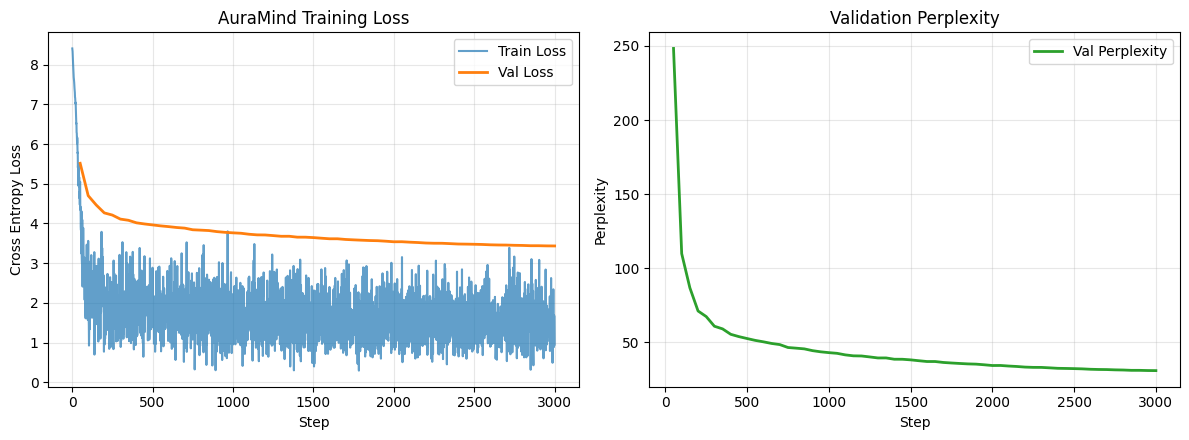

Training plot saved to: /content/auramind/artifacts/training_curves.png


In [22]:
# ============================================================
# 13C. DIAGNOSTICS VISUALIZATION (LOSS + PERPLEXITY)
# ============================================================

if history["step"]:
    steps = history["step"]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    ax1.plot(steps, history["train_loss"], label="Train Loss", color="#1f77b4", alpha=0.7)
    val_steps = [s for s, v in zip(steps, history["val_loss"]) if v is not None]
    val_losses = [v for v in history["val_loss"] if v is not None]
    if val_losses:
        ax1.plot(val_steps, val_losses, label="Val Loss", color="#ff7f0e", lw=2)
    ax1.set_xlabel("Step")
    ax1.set_ylabel("Cross Entropy Loss")
    ax1.set_title("AuraMind Training Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    if val_losses:
        val_ppl = [math.exp(min(v, 20.0)) for v in val_losses]
        ax2.plot(val_steps, val_ppl, label="Val Perplexity", color="#2ca02c", lw=2)
        ax2.set_xlabel("Step")
        ax2.set_ylabel("Perplexity")
        ax2.set_title("Validation Perplexity")
        ax2.legend()
        ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plot_path = ARTIFACT_DIR / "training_curves.png"
    plt.savefig(plot_path, dpi=200)
    plt.show()
    print("Training plot saved to:", plot_path)


## 14. Load the best checkpoint and perform full held-out evaluation

Validation and test are never augmented with synthetic data.


In [23]:
# ============================================================
# 14. BEST CHECKPOINT + FULL EVALUATION
# ============================================================

if not best_path.exists():

    # If a checkpoint was restored but no best checkpoint
    # was created in this exact session, create it now.
    torch.save(
        {
            "model": model.state_dict(),
            "config": config.to_dict(),
            "step": TOTAL_STEPS,
            "best_val_loss": best_val_loss,
        },
        best_path,
    )

best_checkpoint = torch.load(
    best_path,
    map_location="cpu",
)

eval_model = DecoderTransformer(
    config
).cpu()

eval_model.load_state_dict(
    best_checkpoint["model"]
)

eval_model = eval_model.to(
    device
)

eval_model.eval()

full_val_loss = evaluate(
    eval_model,
    val_loader,
    max_batches=(25 if globals().get('SMOKE_TEST', False) else None),
)

full_test_loss = evaluate(
    eval_model,
    test_loader,
    max_batches=(25 if globals().get('SMOKE_TEST', False) else None),
)

val_ppl = math.exp(
    min(
        full_val_loss,
        20,
    )
)

test_ppl = math.exp(
    min(
        full_test_loss,
        20,
    )
)

print("=" * 78)
print("🏆 FINAL HELD-OUT EVALUATION")
print("=" * 78)
print(
    f"Validation loss: {full_val_loss:.4f}"
)
print(
    f"Validation perplexity: {val_ppl:.2f}"
)
print(
    f"Test loss: {full_test_loss:.4f}"
)
print(
    f"Test perplexity: {test_ppl:.2f}"
)
print(
    f"Parameters: {total_params:,}"
)


🏆 FINAL HELD-OUT EVALUATION
Validation loss: 3.4394
Validation perplexity: 31.17
Test loss: 3.4956
Test perplexity: 32.97
Parameters: 12,194,688


## 15. Qualitative generation

Generation includes token-range checks before every embedding lookup and never accesses an invalid vocabulary index.


In [24]:
# ============================================================
# 15. SAFE GENERATION (MIN-P + EMOTION PREFIX + KV CACHING)
# ============================================================

EMOTION_KEYWORDS = {
    "anxious": ["anxious", "anxiety", "nervous", "worried", "worry", "panic", "scared", "fear", "exam", "presentation", "interview", "test"],
    "sad": ["sad", "depressed", "unhappy", "crying", "tears", "hopeless", "grief", "down", "heartbroken", "loss"],
    "lonely": ["lonely", "alone", "isolated", "nobody", "friendless", "abandoned"],
    "overwhelmed": ["overwhelmed", "drowning", "too much", "burnout", "burned out", "exhausted", "tired"],
    "angry": ["angry", "furious", "mad", "frustrated", "irritated", "annoyed"],
    "ashamed": ["ashamed", "embarrassed", "shame", "guilty", "guilt", "humiliated"],
    "hopeful": ["hopeful", "optimistic", "looking forward", "better"],
    "proud": ["proud", "accomplished", "succeeded", "won", "passed"],
    "grateful": ["grateful", "thankful", "blessed", "appreciate"],
    "caring": ["caring", "help", "support", "love", "friend"],
}

def detect_emotion(text):
    text_lower = text.lower()
    for emotion, keywords in EMOTION_KEYWORDS.items():
        for kw in keywords:
            if re.search(rf"\b{re.escape(kw)}\b", text_lower):
                return emotion
    return "anxious"


def top_p_sample(
    logits,
    temperature=0.75,
    top_p=0.90,
    min_p=MIN_P,
    repetition_penalty=REPETITION_PENALTY,
    generated_tokens=None,
):
    if logits.dim() == 1:
        logits = logits.unsqueeze(0)

    # ENHANCEMENT: Repetition Penalty (Keskar et al., 2019)
    if repetition_penalty > 1.0 and generated_tokens:
        for tok_id in generated_tokens:
            if logits[0, tok_id] > 0:
                logits[0, tok_id] /= repetition_penalty
            else:
                logits[0, tok_id] *= repetition_penalty

    # Temperature scaling
    scaled_logits = logits / max(temperature, 1e-5)
    probs = F.softmax(scaled_logits, dim=-1)

    # ENHANCEMENT: Min-p dynamic sampling
    # Filters out tokens whose probability is less than min_p * max_prob
    if min_p > 0.0:
        max_prob = probs.max(dim=-1, keepdim=True).values
        min_p_mask = probs < (min_p * max_prob)
        scaled_logits = scaled_logits.masked_fill(min_p_mask, -float("inf"))

    sorted_logits, sorted_ids = torch.sort(
        scaled_logits,
        descending=True,
    )

    cumulative = torch.cumsum(
        F.softmax(sorted_logits, dim=-1),
        dim=-1,
    )

    remove = cumulative > top_p
    remove[..., 1:] = remove[..., :-1].clone()
    remove[..., 0] = False

    filtered = sorted_logits.masked_fill(
        remove,
        -float("inf"),
    )

    probs = F.softmax(filtered, dim=-1)

    if not torch.isfinite(probs).all():
        raise RuntimeError(
            "Generation probabilities are non-finite."
        )

    sampled_position = torch.multinomial(
        probs,
        num_samples=1,
    )

    return sorted_ids.gather(-1, sampled_position)


@torch.no_grad()
def generate_response(
    user_text,
    emotion=None,
    max_new_tokens=80,
    temperature=0.75,
    top_p=0.90,
    min_p=MIN_P,
    repetition_penalty=REPETITION_PENALTY,
    use_cache=USE_KV_CACHE,
):
    model.eval()

    if emotion is None:
        emotion = detect_emotion(user_text)

    prompt = (
        f"{EMOTION_TOKEN} {emotion}\n"
        f"<|user|> {user_text.strip()}\n"
        f"<|counselor|>"
    )

    ids = tokenizer.encode(prompt).ids
    if not ids:
        raise ValueError("Prompt produced no tokens.")

    generated_ids = []
    seen_tokens = set()

    if use_cache:
        # KV-Cached O(N) Generation
        input_ids = torch.tensor([ids], dtype=torch.long, device=device)
        logits, _, past_kvs = model(input_ids, use_cache=True, offset=0)
        next_logits = logits[:, -1, :]

        next_token = top_p_sample(
            next_logits,
            temperature=temperature,
            top_p=top_p,
            min_p=min_p,
            repetition_penalty=repetition_penalty,
            generated_tokens=seen_tokens,
        ).item()

        if next_token == EOS_ID:
            return ""

        generated_ids.append(next_token)
        seen_tokens.add(next_token)

        offset = len(ids)
        for _ in range(max_new_tokens - 1):
            curr_input = torch.tensor([[next_token]], dtype=torch.long, device=device)
            logits, _, past_kvs = model(
                curr_input,
                past_kvs=past_kvs,
                offset=offset,
                use_cache=True,
            )
            offset += 1
            next_logits = logits[:, -1, :]

            next_token = top_p_sample(
                next_logits,
                temperature=temperature,
                top_p=top_p,
                min_p=min_p,
                repetition_penalty=repetition_penalty,
                generated_tokens=seen_tokens,
            ).item()

            if next_token == EOS_ID:
                break

            generated_ids.append(next_token)
            seen_tokens.add(next_token)

            if offset >= BLOCK_SIZE - 1:
                break
    else:
        # Standard O(N^2) Full-Context Generation
        curr_ids = list(ids)
        for _ in range(max_new_tokens):
            input_tensor = torch.tensor([curr_ids], dtype=torch.long, device=device)
            logits, _ = model(input_tensor, use_cache=False)
            next_logits = logits[:, -1, :]

            next_token = top_p_sample(
                next_logits,
                temperature=temperature,
                top_p=top_p,
                min_p=min_p,
                repetition_penalty=repetition_penalty,
                generated_tokens=seen_tokens,
            ).item()

            if next_token == EOS_ID:
                break

            generated_ids.append(next_token)
            seen_tokens.add(next_token)
            curr_ids.append(next_token)

            if len(curr_ids) >= BLOCK_SIZE:
                break

    decoded = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    return decoded

prompts = [
    "I am feeling really anxious about my exam tomorrow.",
    "I feel like I am falling behind everyone at work.",
    "I have been lonely because my friends seem distant lately.",
    "I am having a difficult time being patient with myself.",
]

generation_results = []

print("=" * 78)
print("🧠 QUALITATIVE GENERATION (EMOTION-CONDITIONED + MIN-P)")
print("=" * 78)

for prompt in prompts:
    print("-" * 78)
    detected = detect_emotion(prompt)
    print(f"USER ({detected}):", prompt)
    try:
        output = generate_response(prompt)
        print("MODEL:")
        print(output)
        generation_results.append({"prompt": prompt, "emotion": detected, "output": output})
    except Exception as exc:
        print("❌ Generation failed:", type(exc).__name__, str(exc))


🧠 QUALITATIVE GENERATION (EMOTION-CONDITIONED + MIN-P)
------------------------------------------------------------------------------
USER (anxious): I am feeling really anxious about my exam tomorrow.
MODEL:
I can hear how important my exam is to you, and how exhausting it has been to sit with these feelings.
.
 It sounds like your mind is trying to protect you by preparing for every possible outcome. We can make room for that fear without assuming the worst-case scenario will happen.
.
 You do not have to solve the whole situation at once; it
------------------------------------------------------------------------------
USER (anxious): I feel like I am falling behind everyone at work.
MODEL:
That is a good idea.
 you will be fine
------------------------------------------------------------------------------
USER (lonely): I have been lonely because my friends seem distant lately.
MODEL:
What is your first time?
?
-----------------------------------------------------------------------

## 16. Automated final integrity tests


In [25]:
# ============================================================
# 16. FINAL INTEGRITY TESTS
# ============================================================

# Dataset leakage.
assert len(
    train_hashes & val_hashes
) == 0

assert len(
    train_hashes & test_hashes
) == 0

assert len(
    val_hashes & test_hashes
) == 0

# Tokenizer.
assert VOCAB_SIZE > 0

for token_id in SPECIAL_IDS.values():
    assert 0 <= token_id < VOCAB_SIZE

# Model.
assert total_params > 0

# Evaluation.
assert math.isfinite(
    full_val_loss
)

assert math.isfinite(
    full_test_loss
)

assert val_ppl > 0
assert test_ppl > 0

# Generation.
assert len(
    generation_results
) > 0

for result in generation_results:

    assert result["prompt"]
    assert result["output"]

# Artifact existence.
required_artifacts = [
    ARTIFACT_DIR / "tokenizer.json",
    ARTIFACT_DIR / "config.json",
    best_path,
    DATA_DIR / "dataset_manifest.json",
    ARTIFACT_DIR / "dataset_quality_report.json",
    ARTIFACT_DIR / "tokenizer_manifest.json",
]

for artifact in required_artifacts:

    if not artifact.exists():
        raise FileNotFoundError(
            f"Missing required artifact: {artifact}"
        )

print("=" * 78)
print("✅ ALL FINAL INTEGRITY TESTS PASSED")
print("=" * 78)


✅ ALL FINAL INTEGRITY TESTS PASSED


## 17. Experiment design and reproducibility

AuraMind is structured so future runs can be compared without changing the
evaluation protocol.

### Recommended comparison

| Run | Training data | Architecture | Purpose |
|---|---|---|---|
| baseline | real only | compact decoder | establish reference |
| augmented | real + synthetic | compact decoder | measure synthetic-data effect |
| AuraMind V3 | real + quality-controlled synthetic | RoPE + RMSNorm + SwiGLU + tied embeddings | evaluate the complete design |

Validation and test data remain real-only. The comparison table should be filled
with **measured results from actual runs**; the notebook does not fabricate
baseline numbers.

### Reproducibility controls

- fixed random seed;
- explicit model configuration;
- saved tokenizer;
- saved checkpoints;
- saved best-validation checkpoint;
- saved evaluation metrics;
- saved artifact checksums;
- explicit data provenance;
- CPU validation before CUDA training;
- token-range checks before embedding lookup.


In [26]:
# ============================================================
# 17A. CURRENT RUN SUMMARY
# ============================================================

current_run_summary = {
    "project": PROJECT,
    "version": VERSION,
    "steps_requested": TOTAL_STEPS,
    "context_length": BLOCK_SIZE,
    "layers": N_LAYER,
    "heads": N_HEAD,
    "embedding_dimension": N_EMBD,
    "parameters": total_params,
    "preserve_dialogue_boundaries": (
        PRESERVE_DIALOGUE_BOUNDARIES
    ),
    "best_validation_loss": (
        best_val_loss
        if math.isfinite(best_val_loss)
        else None
    ),
    "best_validation_step": best_val_step,
}

print(
    json.dumps(
        current_run_summary,
        indent=2,
    )
)

with open(
    ARTIFACT_DIR / "run_summary.json",
    "w",
    encoding="utf-8",
) as handle:

    json.dump(
        current_run_summary,
        handle,
        indent=2,
    )


{
  "project": "AuraMind",
  "version": "V3-PERSONAL-PROJECT",
  "steps_requested": 3000,
  "context_length": 384,
  "layers": 6,
  "heads": 6,
  "embedding_dimension": 384,
  "parameters": 12194688,
  "preserve_dialogue_boundaries": true,
  "best_validation_loss": 3.4327425289154054,
  "best_validation_step": 3000
}


## 18. Final reproducibility manifest

All reported values below are generated from the actual run rather than copied from a previous experiment.


In [27]:
# ============================================================
# 18. FINAL MANIFEST + REPORT
# ============================================================

def sha256_file(path):

    digest = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as handle:

        for chunk in iter(
            lambda: handle.read(
                1024 * 1024
            ),
            b"",
        ):

            digest.update(chunk)

    return digest.hexdigest()

final_model_path = (
    ARTIFACT_DIR
    / "auramind_v2_final.pt"
)

torch.save(
    {
        "model_state_dict":
            eval_model.state_dict(),
        "config":
            config.to_dict(),
        "tokenizer_vocab_size":
            VOCAB_SIZE,
        "special_ids":
            SPECIAL_IDS,
        "metrics": {
            "validation_loss":
                full_val_loss,
            "validation_perplexity":
                val_ppl,
            "test_loss":
                full_test_loss,
            "test_perplexity":
                test_ppl,
        },
    },
    final_model_path,
)

with open(
    ARTIFACT_DIR
    / "qualitative_generation.json",
    "w",
    encoding="utf-8",
) as handle:

    json.dump(
        generation_results,
        handle,
        indent=2,
        ensure_ascii=False,
    )

final_report = {
    "project": PROJECT,
    "version": VERSION,
    "timestamp_utc": time.strftime(
        "%Y-%m-%dT%H:%M:%SZ",
        time.gmtime(),
    ),
    "seed": SEED,
    "device": str(device),
    "gpu": (
        torch.cuda.get_device_name(0)
        if device.type == "cuda"
        else None
    ),
    "architecture": config.to_dict(),
    "parameters": total_params,
    "context_length": config.block_size,
    "dataset": {
        "real_total": len(real_records),
        "real_train": len(real_train),
        "synthetic_train": len(synth_records),
        "validation_real_only": len(real_val),
        "test_real_only": len(real_test),
        "train_total": len(train_records),
    },
    "training": {
        "requested_steps": TOTAL_STEPS,
        "best_validation_step": best_val_step,
        "best_validation_loss": best_val_loss,
        "preserve_dialogue_boundaries": (
            PRESERVE_DIALOGUE_BOUNDARIES
        ),
    },
    "diagnostics": {
        "learning_rate_schedule": "warmup + cosine decay",
        "gradient_clipping": GRAD_CLIP,
        "evaluation_interval": EVAL_INTERVAL,
        "evaluation_batches": EVAL_BATCHES,
    },
    "synthetic_provenance": (
        "template_synthetic_fallback"
    ),
    "synthetic_judge": quality_summary,
    "tokenizer": tokenizer_stats,
    "evaluation": {
        "validation_loss": full_val_loss,
        "validation_perplexity": val_ppl,
        "test_loss": full_test_loss,
        "test_perplexity": test_ppl,
    },
    "leakage": leakage_pairs,
    "notes": [
        "Validation and test contain real human data only.",
        "Synthetic data is restricted to training.",
        "Synthetic examples are explicitly labelled as fallback template data.",
        "Quality scores are deterministic heuristic scores, not human/LLM judge scores.",
        "This model is an empathetic dialogue research prototype and is not a diagnostic system.",
    ],
}

with open(
    ARTIFACT_DIR
    / "final_report.json",
    "w",
    encoding="utf-8",
) as handle:

    json.dump(
        final_report,
        handle,
        indent=2,
        ensure_ascii=False,
    )

artifact_files = [
    final_model_path,
    ARTIFACT_DIR / "best_model.pt",
    ARTIFACT_DIR / "tokenizer.json",
    ARTIFACT_DIR / "config.json",
    ARTIFACT_DIR / "final_report.json",
    ARTIFACT_DIR / "dataset_quality_report.json",
    ARTIFACT_DIR / "tokenizer_manifest.json",
    ARTIFACT_DIR / "qualitative_generation.json",
    ARTIFACT_DIR / "learning_rate_curve.png",
    ARTIFACT_DIR / "gradient_norm_curve.png",
    ARTIFACT_DIR / "run_summary.json",
    DATA_DIR / "dataset_manifest.json",
]

if (ARTIFACT_DIR / "loss_curve.png").exists():
    artifact_files.append(
        ARTIFACT_DIR / "loss_curve.png"
    )

artifact_manifest = {}

for path in artifact_files:

    if path.exists():

        artifact_manifest[
            str(path.relative_to(ROOT))
        ] = {
            "bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }

with open(
    ARTIFACT_DIR
    / "artifact_manifest.json",
    "w",
    encoding="utf-8",
) as handle:

    json.dump(
        artifact_manifest,
        handle,
        indent=2,
    )

# Human-readable final report.
report_lines = [
    "# AuraMind V3 — Personal Project Report",
    "",
    "## Objective",
    "Multi-turn empathetic emotional-support dialogue decoder with dialogue-preserving tensorization and explicit training diagnostics.",
    "",
    "## Dataset",
    f"- Real dialogues: {len(real_records):,}",
    f"- Real training dialogues: {len(real_train):,}",
    f"- Synthetic training dialogues: {len(synth_records):,}",
    f"- Human-only validation dialogues: {len(real_val):,}",
    f"- Human-only test dialogues: {len(real_test):,}",
    f"- Final training dialogues: {len(train_records):,}",
    "",
    "## Tokenizer",
    "- Byte-Level BPE",
    f"- Vocabulary: {VOCAB_SIZE:,}",
    f"- Measured training tokens: {total_tokens:,}",
    f"- Measured UNK rate: {unknown_rate:.8%}",
    "",
    "## Model",
    "- Decoder-only Transformer",
    "- RoPE",
    "- RMSNorm",
    "- SwiGLU",
    "- Causal self-attention",
    "- Weight-tied embeddings",
    f"- Layers: {config.n_layer}",
    f"- Heads: {config.n_head}",
    f"- Embedding dimension: {config.n_embd}",
    f"- Context length: {config.block_size}",
    f"- Parameters: {total_params:,}",
    "",
    "## Evaluation",
    f"- Validation loss: {full_val_loss:.4f}",
    f"- Validation perplexity: {val_ppl:.2f}",
    f"- Held-out test loss: {full_test_loss:.4f}",
    f"- Held-out test perplexity: {test_ppl:.2f}",
    "",
    "## Data Integrity",
    "- Train ∩ Validation: 0",
    "- Train ∩ Test: 0",
    "- Validation ∩ Test: 0",
    "- Synthetic data enters training only.",
    "",
    "## Transparency",
    "- Synthetic provenance: template_synthetic_fallback",
    "- Quality judge: deterministic heuristic_judge",
    "- No synthetic quality score is represented as a human or LLM evaluation.",
    "",
    "## Safety",
    "The system is designed to avoid diagnosis, fake professional credentials, and unsupported medical certainty.",
    "",
]

(ARTIFACT_DIR / "FINAL_REPORT.md").write_text(
    "\n".join(report_lines),
    encoding="utf-8",
)

project_stage(
    "project_packaging",
    100,
    "Final project artifacts, metrics, reports, and checksums created",
)

print("=" * 78)
print("🏆 AURAMIND PERSONAL PROJECT READY")
print("=" * 78)

print(
    f"Validation PPL: {val_ppl:.2f}"
)

print(
    f"Test PPL: {test_ppl:.2f}"
)

print(
    f"Parameters: {total_params:,}"
)

print(
    "Artifacts:",
    ARTIFACT_DIR,
)


[PROJECT] project_packaging | 100% | Final project artifacts, metrics, reports, and checksums created
🏆 AURAMIND PERSONAL PROJECT READY
Validation PPL: 31.17
Test PPL: 32.97
Parameters: 12,194,688
Artifacts: /content/auramind/artifacts


## 19. Optional project backup to Google Drive

Run this only after the entire notebook completes successfully.


In [28]:
# ============================================================
# 19. OPTIONAL GOOGLE DRIVE BACKUP
# ============================================================

try:

    from google.colab import drive

    drive.mount(
        "/content/drive"
    )

    destination = Path(
        "/content/drive/MyDrive/"
        "AuraMind_Personal_Project"
    )

    destination.mkdir(
        parents=True,
        exist_ok=True,
    )

    for path in ARTIFACT_DIR.iterdir():

        if path.is_file():

            shutil.copy2(
                path,
                destination / path.name,
            )

    print(
        "✅ Project artifacts copied to:",
        destination,
    )

except Exception as exc:

    print(
        "ℹ️ Drive export skipped:",
        exc,
    )


ℹ️ Drive export skipped: mount failed


# AuraMind V3 — Personal Project Checklist

Before publishing the repository:

- [ ] Run the notebook from a clean runtime.
- [ ] Confirm the tokenizer is trained and saved successfully.
- [ ] Confirm dialogue-preserving tensorization is enabled.
- [ ] Confirm CPU model verification passes.
- [ ] Confirm CUDA smoke test passes when a GPU is available.
- [ ] Train to the configured step budget.
- [ ] Inspect training, validation, learning-rate, and gradient-norm curves.
- [ ] Confirm the best-validation checkpoint exists.
- [ ] Run full held-out validation and test evaluation.
- [ ] Review qualitative generations manually.
- [ ] Review the heuristic safety/quality evaluation.
- [ ] Keep validation/test data real-only.
- [ ] Do not describe the fallback synthetic generator as LLM-generated data.
- [ ] Do not describe the heuristic judge as human or LLM evaluation.
- [ ] Report measured results rather than estimated or fabricated comparisons.
- [ ] Publish the architecture configuration and reproducibility artifacts.
